In [1]:
from langgraph.graph  import StateGraph,START,END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver # ye buit in check pointer hai memort mein states ko store krwaye ga 

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(
    model = "llama-3.1-8b-instant"
)

In [4]:
# Creating State
class jokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [6]:
def gen_joke(state:jokeState):
    topic = state['topic']
    prompt = f'Generate a joke on given topic - {topic}'
    joke=model.invoke(prompt).content
    return {'joke':  joke}

In [7]:
def exp_joke(state:jokeState):
    topic = state['topic']
    joke = state['joke']
    prompt = f'Give the clear explanation on generated joke - {joke} on topic - {topic}'
    explanation=model.invoke(prompt).content
    return {'explanation':  explanation}

In [11]:
# Create Graph 
graph = StateGraph(jokeState)

# Creating Nodes of graph
graph.add_node("gen_joke",gen_joke)
graph.add_node("exp_joke",exp_joke)

# Create Edges of graph
graph.add_edge(START,"gen_joke")
graph.add_edge("gen_joke","exp_joke")
graph.add_edge("exp_joke",END)

# Creating checkpointers
checkpointer = InMemorySaver() # ye code btaye ga k state ki values checkpointer k through store hon gy memeory mein

# Compile Graph 
workflow = graph.compile(checkpointer=checkpointer)

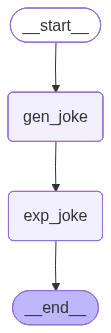

In [9]:
# Visualize the graph 
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [10]:
# Execute Workflow
initial_state = {
    'topic': 'groupwork'
}
workflow.invoke(initial_state)

{'topic': 'groupwork',
 'joke': 'Why did the group project go to therapy?\n\nBecause it was struggling to divide and conquer.',
 'explanation': 'The joke is a play on words, combining two common idioms: "divide and conquer" and the challenges of group work. \n\n"Divide and conquer" is a phrase that originally comes from military strategy, referring to the tactic of dividing an enemy into smaller groups and then conquering them individually. In a business or academic setting, it\'s also used to describe a strategy where a large task is broken down into smaller, more manageable pieces, and then each person or team focuses on one piece.\n\nHowever, in the context of the joke, "divide and conquer" is also a common problem faced in group projects. When multiple people are working together on a project, disagreements and conflicting ideas often arise, making it difficult to come to a consensus. This can lead to frustration, delays, and a sense of struggle among team members.\n\nThe punchline

In [ ]:
config1 = {'configurable':{'thread_id':"1"}}
initial_state = {
    'topic': 'groupwork'
}
workflow.invoke(initial_state, config=config1) # ab thread id 1 k against memeory mein store ho ga

{'topic': 'groupwork',
 'joke': "Why did the group project go to therapy? \n\nBecause it had too many 'divided' opinions and a lot of 'shared' responsibility.",
 'explanation': 'The joke is a play on words, making a pun on the common issues that arise in group projects. Here\'s a breakdown of the joke:\n\n1. "Why did the group project go to therapy?" - This sets the stage for the punchline, implying that the group project is seeking help for some kind of problem.\n\n2. "Because it had too many \'divided\' opinions" - In group projects, it\'s common for team members to have differing opinions on how to approach a task or solve a problem. The word "divided" has a double meaning here - it refers to the differences in opinion, but it also implies that the opinions are "divided" among the team members.\n\n3. "and a lot of \'shared\' responsibility" - This is the second part of the joke. In group projects, team members often share the responsibility of completing tasks and contributing to th

In [20]:
config2 = {'configurable':{'thread_id':"2"}}
initial_state = {
    'topic': 'pizza'
}
workflow.invoke(initial_state, config=config2)

{'topic': 'pizza',
 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling crusty.',
 'explanation': 'That\'s a classic joke. The joke is a play on words, using the phrase "feeling crusty" in a double sense:\n\n1. **Literal meaning**: In this context, "crusty" refers to the crust of a pizza, which is a characteristic feature of the food.\n2. **Idiomatic meaning**: "Feeling crusty" is also an idiomatic expression that means being in a bad mood, irritable, or grumpy.\n\nThe joke relies on this wordplay to create a pun, connecting the literal meaning of the pizza\'s crust to the idiomatic expression of being in a bad mood. The punchline "Because it was feeling crusty" is a clever and unexpected twist that creates humor.'}

In [ ]:
workflow.get_state(config1) # config1 k against jo bhi final state value store hon gy wo de ga

StateSnapshot(values={'topic': 'groupwork', 'joke': "Why did the group project go to therapy? \n\nBecause it had too many 'divided' opinions and a lot of 'shared' responsibility.", 'explanation': 'The joke is a play on words, making a pun on the common issues that arise in group projects. Here\'s a breakdown of the joke:\n\n1. "Why did the group project go to therapy?" - This sets the stage for the punchline, implying that the group project is seeking help for some kind of problem.\n\n2. "Because it had too many \'divided\' opinions" - In group projects, it\'s common for team members to have differing opinions on how to approach a task or solve a problem. The word "divided" has a double meaning here - it refers to the differences in opinion, but it also implies that the opinions are "divided" among the team members.\n\n3. "and a lot of \'shared\' responsibility" - This is the second part of the joke. In group projects, team members often share the responsibility of completing tasks and

In [21]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling crusty.', 'explanation': 'That\'s a classic joke. The joke is a play on words, using the phrase "feeling crusty" in a double sense:\n\n1. **Literal meaning**: In this context, "crusty" refers to the crust of a pizza, which is a characteristic feature of the food.\n2. **Idiomatic meaning**: "Feeling crusty" is also an idiomatic expression that means being in a bad mood, irritable, or grumpy.\n\nThe joke relies on this wordplay to create a pun, connecting the literal meaning of the pizza\'s crust to the idiomatic expression of being in a bad mood. The punchline "Because it was feeling crusty" is a clever and unexpected twist that creates humor.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0fc16e-fb34-6af5-8002-0d139f09dd5b'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-01-28T06:59:48.947019+00:00', par

In [ ]:
list(workflow.get_state_history(config1)) # 4 checkpointers thy to sb ki value dekhne ko milein gy  intermediate value + final value


[StateSnapshot(values={'topic': 'groupwork', 'joke': "Why did the group project go to therapy? \n\nBecause it had too many 'divided' opinions and a lot of 'shared' responsibility.", 'explanation': 'The joke is a play on words, making a pun on the common issues that arise in group projects. Here\'s a breakdown of the joke:\n\n1. "Why did the group project go to therapy?" - This sets the stage for the punchline, implying that the group project is seeking help for some kind of problem.\n\n2. "Because it had too many \'divided\' opinions" - In group projects, it\'s common for team members to have differing opinions on how to approach a task or solve a problem. The word "divided" has a double meaning here - it refers to the differences in opinion, but it also implies that the opinions are "divided" among the team members.\n\n3. "and a lot of \'shared\' responsibility" - This is the second part of the joke. In group projects, team members often share the responsibility of completing tasks an

In [22]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling crusty.', 'explanation': 'That\'s a classic joke. The joke is a play on words, using the phrase "feeling crusty" in a double sense:\n\n1. **Literal meaning**: In this context, "crusty" refers to the crust of a pizza, which is a characteristic feature of the food.\n2. **Idiomatic meaning**: "Feeling crusty" is also an idiomatic expression that means being in a bad mood, irritable, or grumpy.\n\nThe joke relies on this wordplay to create a pun, connecting the literal meaning of the pizza\'s crust to the idiomatic expression of being in a bad mood. The punchline "Because it was feeling crusty" is a clever and unexpected twist that creates humor.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0fc16e-fb34-6af5-8002-0d139f09dd5b'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-01-28T06:59:48.947019+00:00', pa

# Time Travel

In [24]:
workflow.get_state({'configurable':{'thread_id':"2","checkpoint_id":'1f0fc16e-f0d8-6000-8000-cb9b208d11d2'}})

StateSnapshot(values={'topic': 'pizza'}, next=('gen_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f0fc16e-f0d8-6000-8000-cb9b208d11d2'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-01-28T06:59:47.860479+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0fc16e-f0d7-6fff-bfff-529cda341e67'}}, tasks=(PregelTask(id='503c061f-b71e-06b1-553a-6459e4c63cbb', name='gen_joke', path=('__pregel_pull', 'gen_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling crusty.'}),), interrupts=())

In [25]:
workflow.invoke(None, {'configurable':{'thread_id':"2","checkpoint_id":'1f0fc16e-f0d8-6000-8000-cb9b208d11d2'}})

{'topic': 'pizza',
 'joke': 'Why did the pizza go to therapy?\n\nBecause it was feeling crusty and had a lot of dough to work through.',
 'explanation': 'This joke is a play on words, combining a pun with a common idiomatic expression. Here\'s a breakdown:\n\n- "Crusty" is a characteristic of the crust on a pizza, but it\'s also an adjective used to describe someone who is irritable or short-tempered. In this joke, it\'s used as both.\n- "Dough" has a double meaning as well. In baking, dough is the mixture of flour, water, and other ingredients used to make bread or pizza. However, in a therapeutic context, "dough" is a slang term for money, but it\'s also used as a colloquialism for the emotional or psychological challenges people face.\n- The phrase "had a lot of dough to work through" is a play on the common idiomatic expression "had a lot of stuff to work through," which means to have a lot of emotional baggage or problems to resolve. In this joke, the pizza replaces "stuff" with "

In [26]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy?\n\nBecause it was feeling crusty and had a lot of dough to work through.', 'explanation': 'This joke is a play on words, combining a pun with a common idiomatic expression. Here\'s a breakdown:\n\n- "Crusty" is a characteristic of the crust on a pizza, but it\'s also an adjective used to describe someone who is irritable or short-tempered. In this joke, it\'s used as both.\n- "Dough" has a double meaning as well. In baking, dough is the mixture of flour, water, and other ingredients used to make bread or pizza. However, in a therapeutic context, "dough" is a slang term for money, but it\'s also used as a colloquialism for the emotional or psychological challenges people face.\n- The phrase "had a lot of dough to work through" is a play on the common idiomatic expression "had a lot of stuff to work through," which means to have a lot of emotional baggage or problems to resolve. In this joke, the pizza rep